In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.io as sio
import numpy as np
import h5py
import cv2

import matplotlib.pyplot as plt

In [75]:
class FDnCNNColor(nn.Module):
    def __init__(self, depth=20, n_channels=64):
        super(FDnCNNColor, self).__init__()
        kernel_size = 3
        padding = 1
        layers = []

        # 1. Première couche : Entrée = 4 canaux (RGB + Noise Map)
        layers.append(nn.Conv2d(in_channels=4, out_channels=n_channels, 
                                kernel_size=kernel_size, padding=padding, bias=True))
        layers.append(nn.ReLU(inplace=True))
        
        # 2. Couches intermédiaires : Conv + BatchNorm + ReLU
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(in_channels=n_channels, out_channels=n_channels, 
                                    kernel_size=kernel_size, padding=padding, bias=False))
            layers.append(nn.BatchNorm2d(n_channels, eps=0.0001, momentum=0.95))
            layers.append(nn.ReLU(inplace=True))
            
        # 3. Dernière couche : Sortie = 3 canaux (Résidu RGB)
        layers.append(nn.Conv2d(in_channels=n_channels, out_channels=3, 
                                kernel_size=kernel_size, padding=padding, bias=False))
        
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x, noise_level=0.0):
        """
        x: Tenseur de l'image RGB [Batch, 3, H, W]
        noise_level: Le niveau de bruit à injecter dans le 4ème canal (ex: 15/255)
                     Pour de la détection de rééchantillonnage, on peut le laisser à 0.0.
        """
        # Créer la Noise Map (4ème canal) à la même taille que l'image
        noise_map = torch.full((x.size(0), 1, x.size(2), x.size(3)), noise_level, dtype=x.dtype, device=x.device)
        
        # Concaténer l'image RGB et la Noise Map pour obtenir 4 canaux
        x_input = torch.cat([x, noise_map], dim=1)
        
        # Prédire le résidu
        residual = self.dncnn(x_input)
        return residual

In [76]:
def _read_mat_value(f, ref):
    if isinstance(ref, h5py.Reference):
        obj = f[ref]
    else:
        obj = f['#refs#'][str(int(ref))]

    if isinstance(obj, h5py.Dataset):
        return np.array(obj)
    if isinstance(obj, h5py.Group) and 'weights' in obj:
        nested = obj['weights'][:].flatten()
        if len(nested) == 1 and isinstance(nested[0], h5py.Reference):
            nested_obj = f[nested[0]]
            if isinstance(nested_obj, h5py.Dataset):
                return np.array(nested_obj)
    return None


def load_fdncnn_from_mat(mat_path, depth=17, n_channels=64, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FDnCNNColor(depth=depth, n_channels=n_channels).to(device)

    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    bn_layers = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]

    with h5py.File(mat_path, 'r') as f:
        layer_refs = f['net']['layers'][:].flatten()
        conv_i = 0
        bn_i = 0

        for ref in layer_refs:
            layer = f[ref]
            if 'weights' not in layer:
                continue

            values = [_read_mat_value(f, r) for r in layer['weights'][:].flatten()]
            values = [v for v in values if v is not None]
            if not values:
                continue

            first = values[0]

            if first.ndim == 4 and conv_i < len(conv_layers):
                conv = conv_layers[conv_i]
                conv.weight.data.copy_(torch.from_numpy(first.transpose(0, 1, 3, 2)).float())
                if len(values) > 1 and conv.bias is not None:
                    conv.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                conv_i += 1

            elif first.ndim in (1, 2) and bn_i < len(bn_layers):
                bn = bn_layers[bn_i]
                bn.weight.data.copy_(torch.from_numpy(values[0].reshape(-1)).float())
                bn.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                if len(values) > 2:
                    bn.running_mean.data.copy_(torch.from_numpy(values[2].reshape(-1)).float())
                if len(values) > 3:
                    bn.running_var.data.copy_(torch.from_numpy(values[3].reshape(-1)).float())
                bn_i += 1

    model.eval()
    return model


In [92]:
class DnCNNGray(nn.Module):
    def __init__(self, depth=20, n_channels=64):
        super(DnCNNGray, self).__init__()
        layers = []
        layers.append(nn.Conv2d(1, n_channels, kernel_size=3, padding=1, bias=True))
        layers.append(nn.ReLU(inplace=True))
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(n_channels, eps=0.0001, momentum=0.95))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(n_channels, 1, kernel_size=3, padding=1, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        return self.dncnn(x)


def load_dncnn_gray_from_mat(mat_path, depth=20, n_channels=64, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DnCNNGray(depth=depth, n_channels=n_channels).to(device)

    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    bn_layers = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]

    with h5py.File(mat_path, 'r') as f:
        layer_refs = f['net']['layers'][:].flatten()
        conv_i = 0
        bn_i = 0

        for ref in layer_refs:
            layer = f[ref]
            if 'weights' not in layer:
                continue

            values = [_read_mat_value(f, r) for r in layer['weights'][:].flatten()]
            values = [v for v in values if v is not None]
            if not values:
                continue

            first = values[0]

            if first.ndim == 4 and conv_i < len(conv_layers):
                conv = conv_layers[conv_i]
                conv.weight.data.copy_(torch.from_numpy(first.transpose(0, 1, 3, 2)).float())
                if len(values) > 1 and conv.bias is not None:
                    conv.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                conv_i += 1

            elif first.ndim in (1, 2) and bn_i < len(bn_layers):
                bn = bn_layers[bn_i]
                bn.weight.data.copy_(torch.from_numpy(values[0].reshape(-1)).float())
                bn.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                if len(values) > 2:
                    bn.running_mean.data.copy_(torch.from_numpy(values[2].reshape(-1)).float())
                if len(values) > 3:
                    bn.running_var.data.copy_(torch.from_numpy(values[3].reshape(-1)).float())
                bn_i += 1

    model.eval()
    return model

In [77]:


class MaskSim(nn.Module):
    def __init__(self, dncnn_model, image_size=256, in_channels=3):
        """
        Architecture complète de MaskSim pour la détection d'images de synthèse.
        
        Paramètres:
        - dncnn_model: L'instance du modèle DnCNN pré-entraîné.
        - image_size (int): Taille de l'image (les images doivent être croppées/redimensionnées en carré).
        - in_channels (int): 3 pour RGB, 1 pour Niveaux de gris.
        """
        super(MaskSim, self).__init__()
        
        # 1. Le Filtre Prétraité (DnCNN)
        self.filter = dncnn_model
        
        # Généralement, on gèle les poids du DnCNN car il agit comme un extracteur de base
        for param in self.filter.parameters():
            param.requires_grad = False
            
        # 2. Couche d'amélioration (Conv 1x1)
        # Permet de combiner linéairement les canaux de fréquence (ex: R, G, B)
        self.enhancement = nn.Conv2d(in_channels=in_channels, 
                                     out_channels=in_channels, 
                                     kernel_size=1, 
                                     bias=True)
        
        # 3. Masque d'apprentissage (Learnable Mask)
        # Initialisé à 1, il va apprendre à masquer (mettre à 0) les fréquences inutiles
        self.mask = nn.Parameter(torch.ones(1, in_channels, image_size, image_size))
        
        # 4. Motif de référence (Reference Spectrum)
        # C'est "l'empreinte digitale" spectrale d'une image générée par IA que le modèle va apprendre
        self.reference_pattern = nn.Parameter(torch.randn(1, in_channels, image_size, image_size))

    def forward(self, x):
        # --- ÉTAPE 1 : Extraction du résidu (bruit) ---
        with torch.no_grad():
            residual = self.filter(x)
            
        # --- ÉTAPE 2 : Transformée de Fourier 2D ---
        # Calcul de la FFT 2D complexe
        fft_complex = torch.fft.fft2(residual)
        # Décalage pour centrer les basses fréquences (très important en analyse spectrale)
        fft_shifted = torch.fft.fftshift(fft_complex, dim=(-2, -1))
        
        # Calcul du spectre d'amplitude logarithmique
        # L'ajout de 1e-8 évite l'erreur mathématique log(0)
        magnitude = torch.abs(fft_shifted)
        log_magnitude = torch.log(magnitude + 1e-8)
        
        # --- ÉTAPE 3 : Amélioration et Masquage ---
        enhanced_spectrum = self.enhancement(log_magnitude)
        
        # Multiplication élément par élément (Hadamard) avec le masque
        masked_spectrum = enhanced_spectrum * self.mask
        
        # --- ÉTAPE 4 : Calcul de Similarité ---
        # On aplatit les tenseurs pour comparer globalement l'image avec le motif de référence
        batch_size = masked_spectrum.size(0)
        flat_masked = masked_spectrum.view(batch_size, -1)
        flat_reference = self.reference_pattern.view(1, -1).expand(batch_size, -1)
        
        # Similarité Cosinus entre le spectre de l'image et l'empreinte IA apprise
        similarity_score = F.cosine_similarity(flat_masked, flat_reference, dim=1)
        
        # Retourne le score (qui peut servir de logit/probabilité) 
        # et le spectre masqué (utile pour la visualisation et l'explicabilité de MaskSim)
        return similarity_score, masked_spectrum

Text(0.5, 1.0, 'Image originale')

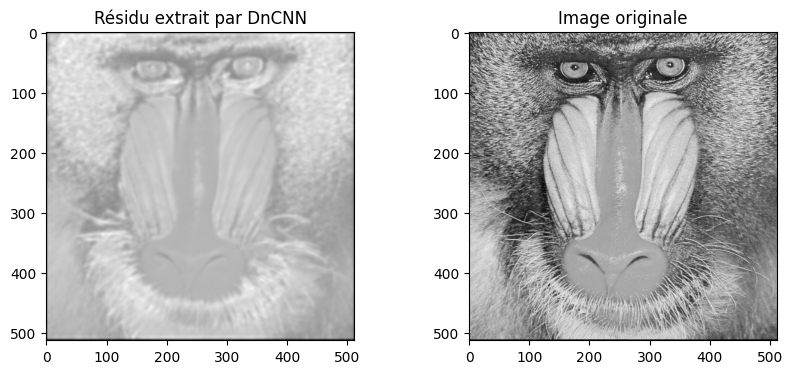

In [94]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Charger directement le modèle pré-entraîné pour noir et blanc
model = load_dncnn_gray_from_mat('DnCNN3.mat', depth=20, device=device)

# Test rapide sur une image en niveaux de gris
image_path = 'babbon.png'
x = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
x = torch.from_numpy(x).float().unsqueeze(0).unsqueeze(0) / 255.0
x = x.to(device)
with torch.no_grad():
    residual = model(x)

residual_vis = residual[0, 0].detach().cpu()
residual_vis = residual_vis - residual_vis.min()
residual_vis = residual_vis / (residual_vis.max() + 1e-8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(residual_vis, cmap='gray')
plt.title("Résidu extrait par DnCNN")

plt.subplot(1, 2, 2)
plt.imshow(x[0, 0].cpu().numpy(), cmap='gray')
plt.title("Image originale")

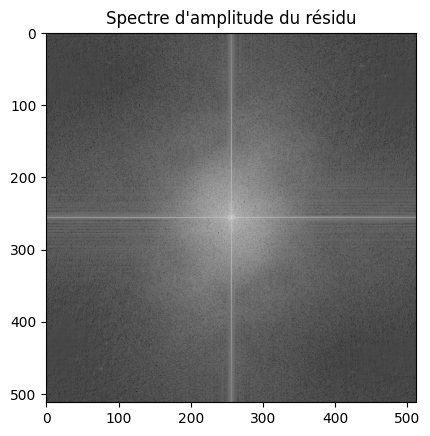

In [95]:
plt.imshow(np.fft.fftshift(np.log(np.abs(np.fft.fft2(residual_vis.cpu().numpy())) + 1e-8)), cmap='gray')
plt.title("Spectre d'amplitude du résidu")
plt.show()